In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thêm thư mục gốc vào đường dẫn hệ thống để import được src
sys.path.append(os.path.abspath('..'))

# Import các module bạn vừa viết
from src.data.loader import DataLoader
from src.mining.association import AssociationMiner
from src.mining.clustering import ClusterMiner

# Cấu hình hiển thị
sns.set(style="whitegrid")

In [2]:
# Load dữ liệu từ folder data/raw
DATA_PATH = '../data/raw/ai4i2020.csv'
loader = DataLoader(DATA_PATH)
df = loader.load_data()
df.head()

-> Đã load dữ liệu: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# 1. Rời rạc hóa dữ liệu (Binning)
cols_obs = ['Air temperature [K]', 'Process temperature [K]', 
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
df_bin = loader.discretize_data(df, cols_obs)

# 2. Chạy thuật toán tìm luật
assoc_miner = AssociationMiner(min_support=0.005, min_lift=1.5)
rules = assoc_miner.mine_rules(df_bin)

# 3. Lọc luật lỗi và hiển thị
failure_rules = assoc_miner.filter_failure_rules(rules)
print("TOP 10 LUẬT DẪN ĐẾN LỖI MÁY:")
display(failure_rules[['antecedents', 'consequents', 'lift', 'confidence']].head(10))

# Lưu kết quả ra file csv (nằm trong thư mục notebooks)
failure_rules.to_csv('ket_qua_luat_loi.csv', index=False)

-> Đang chạy Apriori (min_support=0.005)...
TOP 10 LUẬT DẪN ĐẾN LỖI MÁY:


,antecedents,consequents,lift,confidence
3861,"(Air temperature [K]_Bin_High, Process tempera...","(Status_Failure, Torque [Nm]_Bin_High)",8.168431,0.216463
3860,"(Process temperature [K]_Bin_Medium, Torque [N...","(Status_Failure, Rotational speed [rpm]_Bin_Low)",8.039678,0.213855
3851,"(Process temperature [K]_Bin_Medium, Air tempe...",(Status_Failure),7.933315,0.268939
4135,"(Torque [Nm]_Bin_High, Air temperature [K]_Bin...","(Status_Failure, Rotational speed [rpm]_Bin_Lo...",7.498750,0.076487
4126,"(Air temperature [K]_Bin_High, Torque [Nm]_Bin...","(Status_Failure, Process temperature [K]_Bin_H...",7.382428,0.095972
4137,"(Air temperature [K]_Bin_High, Rotational spee...","(Status_Failure, Torque [Nm]_Bin_High, Process...",7.375437,0.076705
4723,"(Tool wear [min]_Bin_High, Torque [Nm]_Bin_Hig...","(Status_Failure, Rotational speed [rpm]_Bin_Low)",7.150441,0.190202
4724,"(Tool wear [min]_Bin_High, Air temperature [K]...","(Status_Failure, Torque [Nm]_Bin_High)",7.136292,0.189112
4714,"(Tool wear [min]_Bin_High, Air temperature [K]...",(Status_Failure),6.953224,0.235714
1014,"(Rotational speed [rpm]_Bin_Low, Air temperatu...",(Status_Failure),6.655155,0.225610


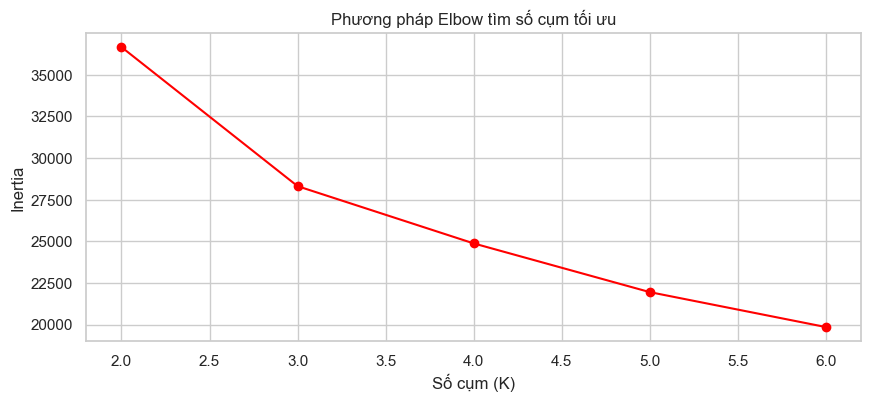

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure_Rate_%,Count
Cluster,,,,,,,
0,301.723308,311.246590,1469.807379,43.643333,110.358270,5.241730,3930
1,298.264252,308.741524,1474.144884,43.264600,104.624844,2.165795,4017
2,300.121383,310.103166,1797.261568,26.574233,109.850950,2.240623,2053


In [4]:
# 1. Khởi tạo và Chuẩn hóa dữ liệu
cluster_miner = ClusterMiner(n_clusters=3) # Giả sử chọn K=3
X_scaled = cluster_miner.preprocess(df, cols_obs)

# 2. Tìm K tối ưu (Vẽ biểu đồ Elbow)
inertia, sil_scores = cluster_miner.find_optimal_k(X_scaled)

plt.figure(figsize=(10, 4))
plt.plot(range(2, 7), inertia, marker='o', color='red')
plt.title('Phương pháp Elbow tìm số cụm tối ưu')
plt.xlabel('Số cụm (K)')
plt.ylabel('Inertia')
plt.show()

# 3. Chạy phân cụm và gán nhãn
df_clustered = cluster_miner.fit_predict(df, X_scaled)

# 4. Profiling (Xem đặc điểm từng nhóm máy)
profile = cluster_miner.profile_clusters(df_clustered)
display(profile)

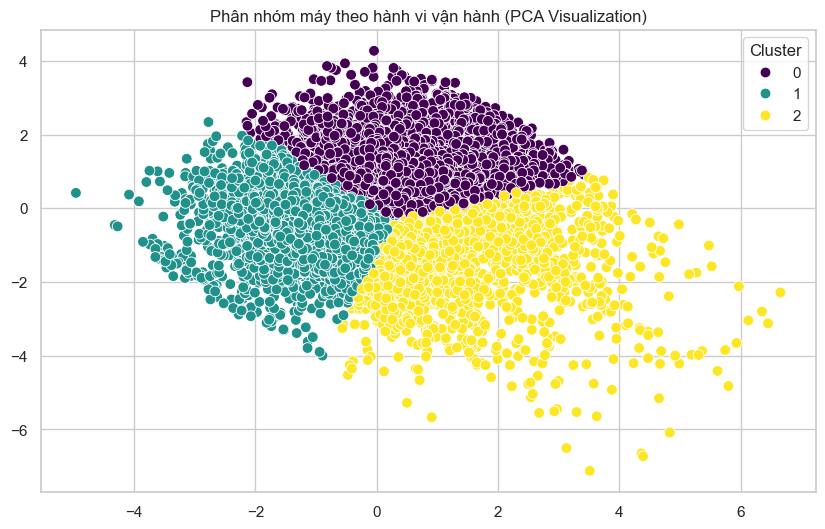

In [5]:
# Giảm chiều xuống 2D để vẽ
X_pca = cluster_miner.get_pca_2d(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_clustered['Cluster'], palette='viridis', s=60)
plt.title('Phân nhóm máy theo hành vi vận hành (PCA Visualization)')
plt.show()